# Gradient of RNN

Number of classes: 2
Vocabulary size: 30522
Epoch 1: Train Acc = 0.602, Val Acc = 0.662
Epoch 2: Train Acc = 0.756, Val Acc = 0.750
Epoch 3: Train Acc = 0.857, Val Acc = 0.853
Epoch 4: Train Acc = 0.907, Val Acc = 0.871
Epoch 5: Train Acc = 0.934, Val Acc = 0.874
Epoch 6: Train Acc = 0.958, Val Acc = 0.872
Epoch 7: Train Acc = 0.972, Val Acc = 0.865
Epoch 8: Train Acc = 0.981, Val Acc = 0.867
Epoch 9: Train Acc = 0.988, Val Acc = 0.874
Epoch 10: Train Acc = 0.989, Val Acc = 0.867
Training time for GRUClassifier: 379.71 seconds
['embedding.weight', 'gru.weight_ih_l0', 'gru.weight_hh_l0', 'gru.bias_ih_l0', 'gru.bias_hh_l0', 'fc.weight', 'fc.bias']


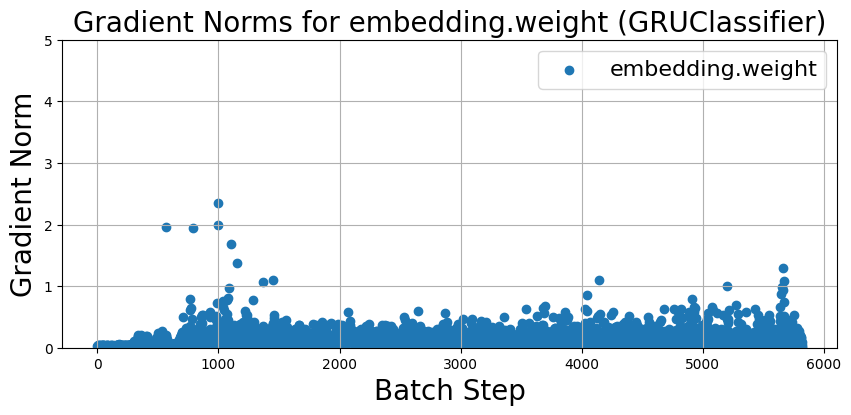

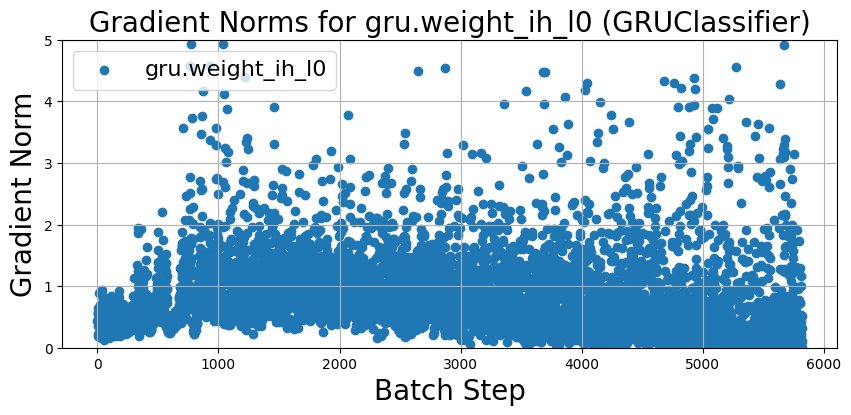

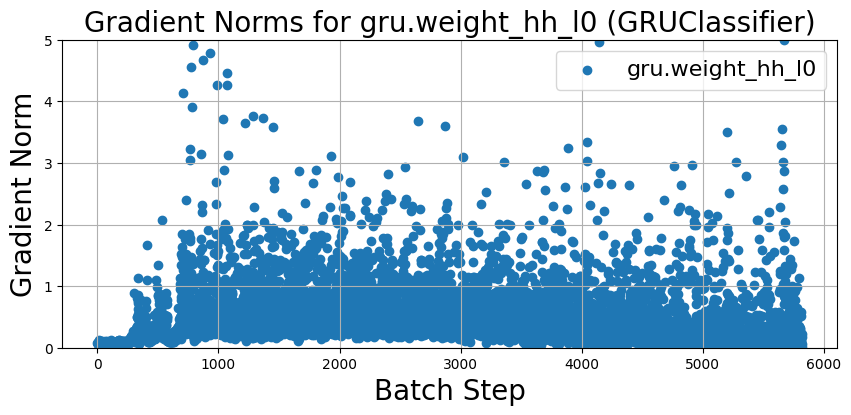

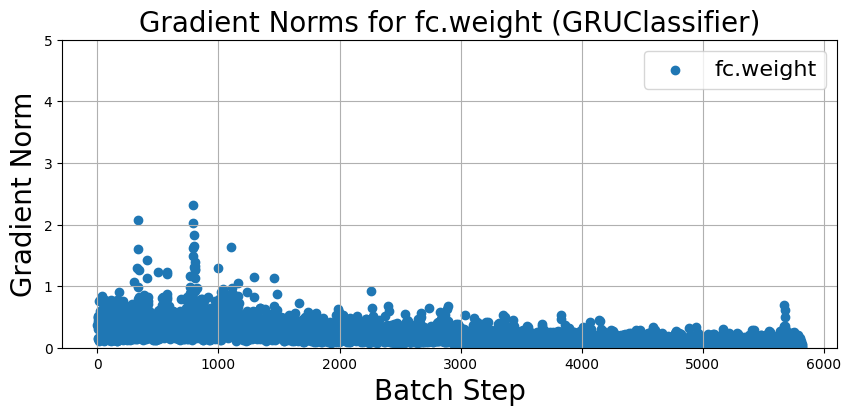

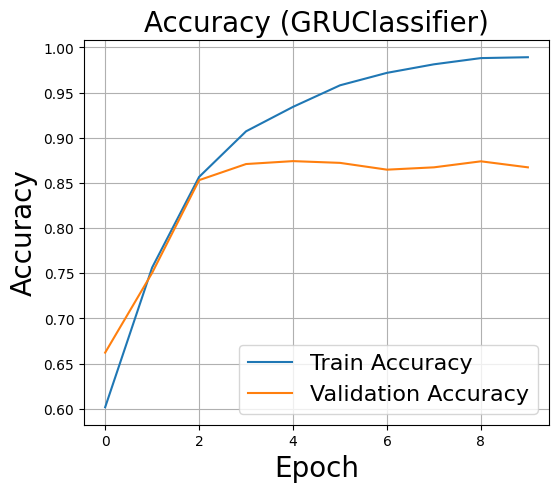

Epoch 1: Train Acc = 0.622, Val Acc = 0.710
Epoch 2: Train Acc = 0.725, Val Acc = 0.764
Epoch 3: Train Acc = 0.801, Val Acc = 0.787
Epoch 4: Train Acc = 0.845, Val Acc = 0.734
Epoch 5: Train Acc = 0.865, Val Acc = 0.838
Epoch 6: Train Acc = 0.901, Val Acc = 0.810
Epoch 7: Train Acc = 0.836, Val Acc = 0.814
Epoch 8: Train Acc = 0.885, Val Acc = 0.819
Epoch 9: Train Acc = 0.920, Val Acc = 0.846
Epoch 10: Train Acc = 0.937, Val Acc = 0.849
Training time for LSTMClassifier: 375.75 seconds
['embedding.weight', 'lstm.weight_ih_l0', 'lstm.weight_hh_l0', 'lstm.bias_ih_l0', 'lstm.bias_hh_l0', 'fc.weight', 'fc.bias']


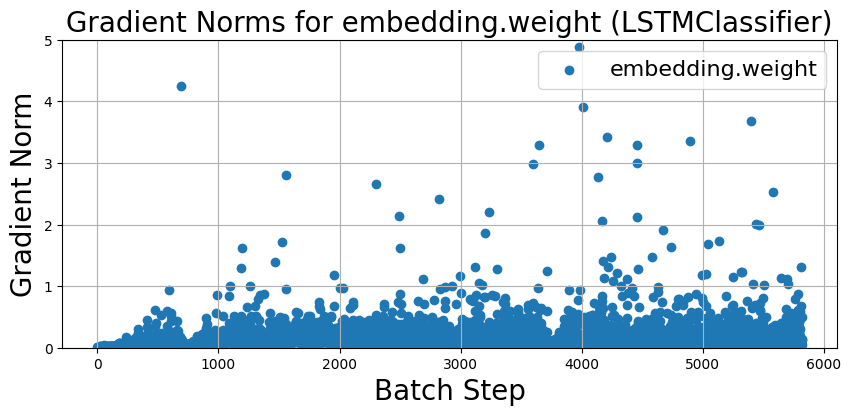

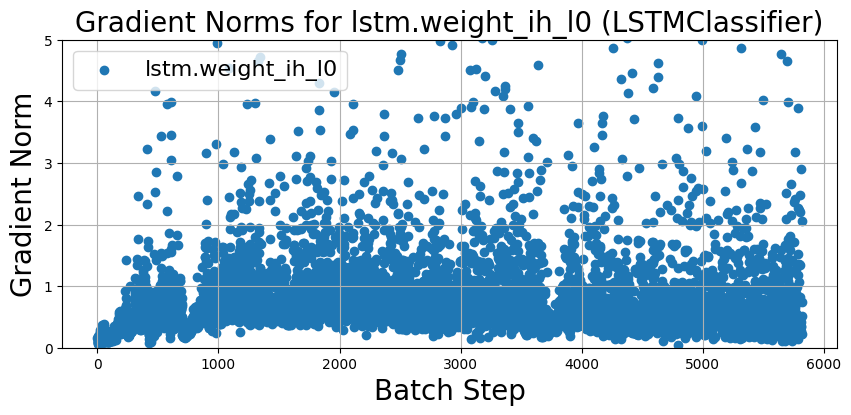

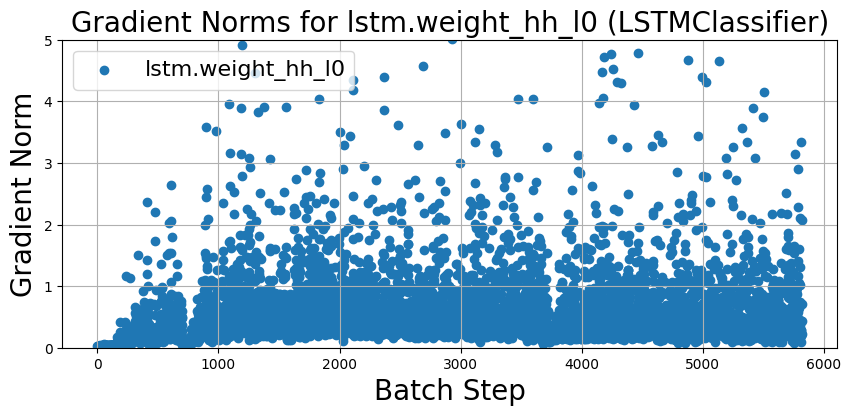

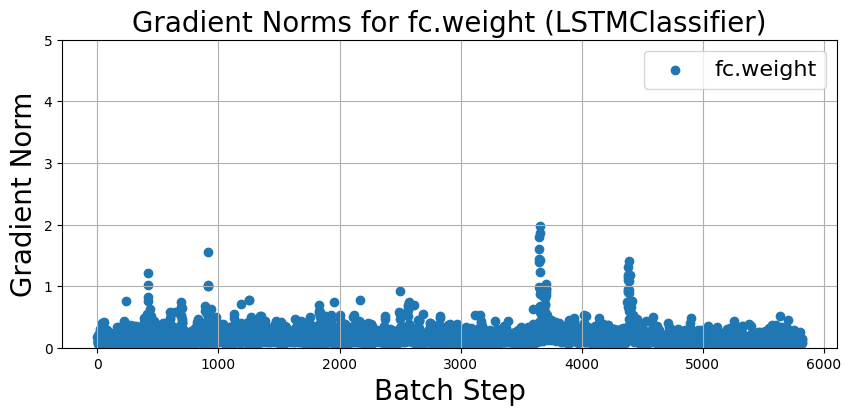

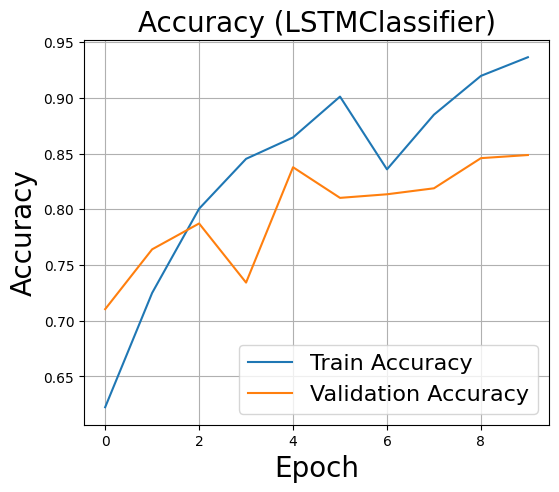

Epoch 1: Train Acc = 0.562, Val Acc = 0.583
Epoch 2: Train Acc = 0.639, Val Acc = 0.646
Epoch 3: Train Acc = 0.702, Val Acc = 0.652
Epoch 4: Train Acc = 0.750, Val Acc = 0.708
Epoch 5: Train Acc = 0.765, Val Acc = 0.726
Epoch 6: Train Acc = 0.689, Val Acc = 0.632
Epoch 7: Train Acc = 0.774, Val Acc = 0.608
Epoch 8: Train Acc = 0.767, Val Acc = 0.682
Epoch 9: Train Acc = 0.838, Val Acc = 0.673
Epoch 10: Train Acc = 0.864, Val Acc = 0.733
Training time for RNNClassifier: 364.30 seconds
['embedding.weight', 'rnn.weight_ih_l0', 'rnn.weight_hh_l0', 'rnn.bias_ih_l0', 'rnn.bias_hh_l0', 'fc.weight', 'fc.bias']


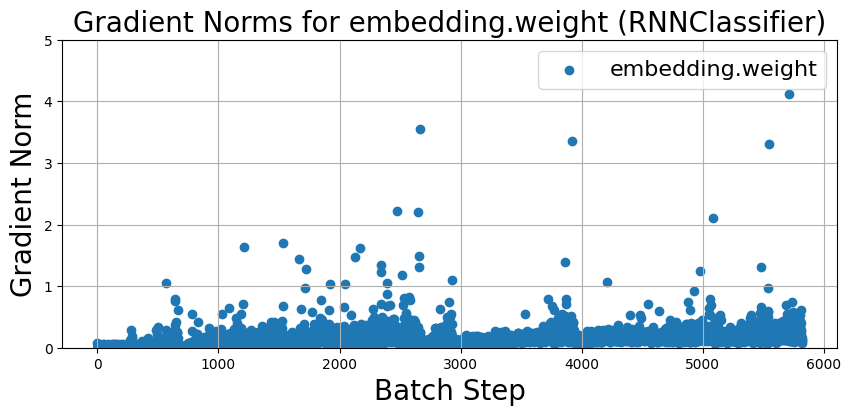

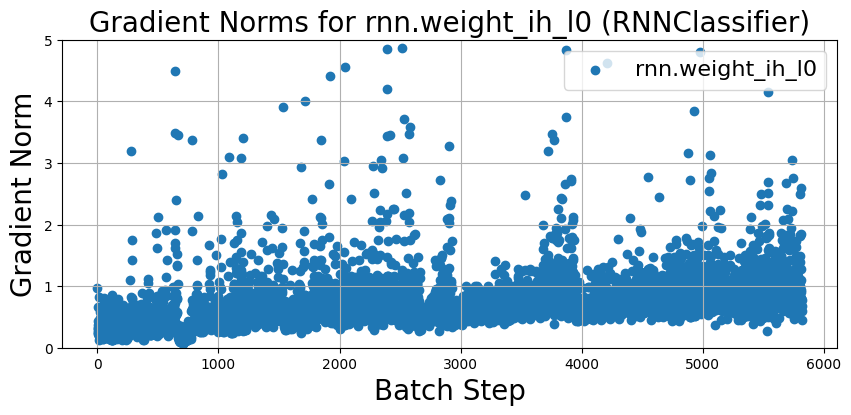

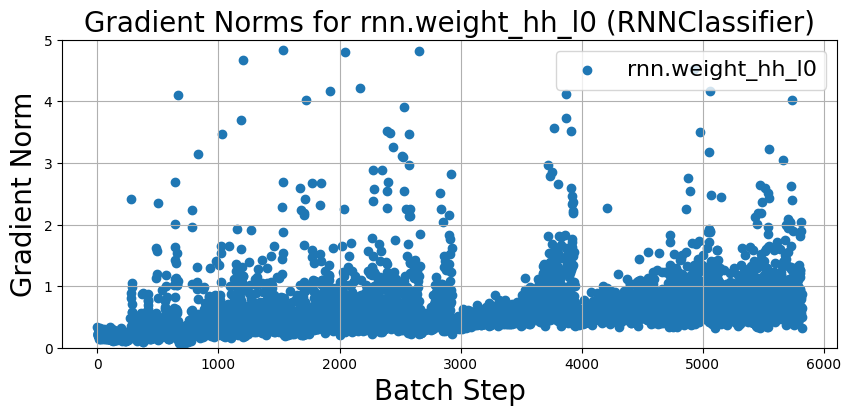

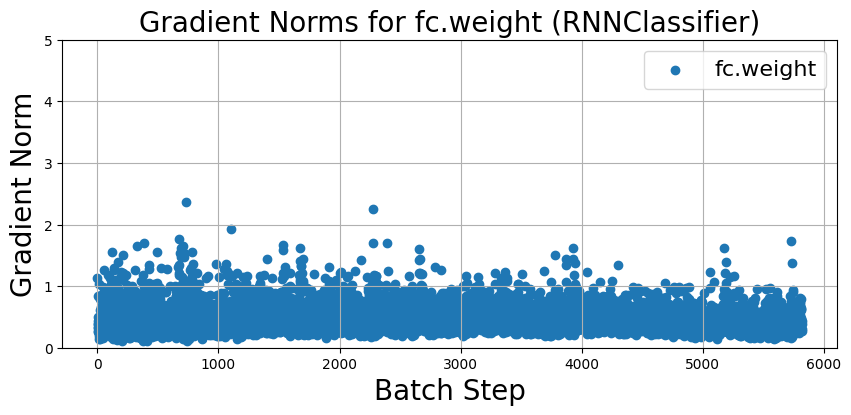

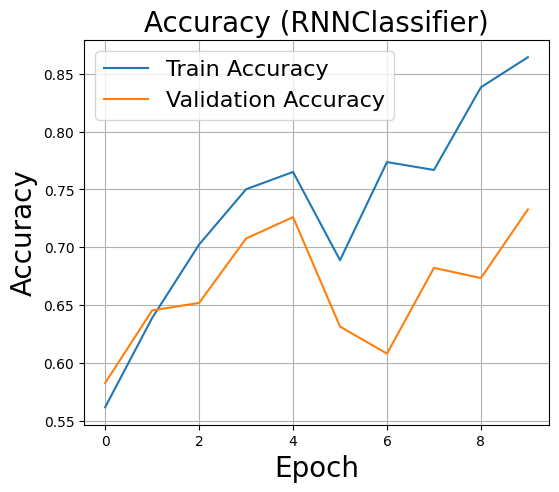

In [1]:
# (1) Data Loading
from datasets import load_dataset
dataset = load_dataset("imdb")
num_classes = len(dataset["train"].features["label"].names)
print(f"Number of classes: {num_classes}")

# (2) Tokenize
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
vocab_size = tokenizer.vocab_size
print(f"Vocabulary size: {vocab_size}")

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding=False)

tokenized = dataset.map(tokenize, batched=True)
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# Filter short sequences (< 100 tokens)
tokenized = tokenized.filter(lambda x: len(x["input_ids"]) >= 100)

# (3) DataLoader with padding
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

def collate_fn(batch):
    input_ids = pad_sequence([x["input_ids"] for x in batch], batch_first=True, padding_value=tokenizer.pad_token_id)
    attn_mask = pad_sequence([x["attention_mask"] for x in batch], batch_first=True, padding_value=0)
    labels = torch.tensor([x["label"] for x in batch])
    return input_ids, attn_mask, labels

tokenized_trainval = tokenized["train"].train_test_split(test_size=0.2, seed=42)
train_loader = DataLoader(tokenized_trainval["train"], batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(tokenized_trainval["test"], batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(tokenized["test"], batch_size=64, shuffle=False, collate_fn=collate_fn)

# (4) Model Definition
import torch.nn as nn

# RNN Classifier
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        emb = self.embedding(input_ids)
        lengths = attention_mask.sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)
        _, hn = self.rnn(packed)
        return self.fc(hn[-1])

# LSTM Classifier
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, bidirectional=False, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        emb = self.embedding(input_ids)
        lengths = attention_mask.sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)
        _, (hn, _) = self.lstm(packed)
        return self.fc(hn[-1])

# GRU Classifier
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)
        self.gru = nn.GRU(embed_dim, hidden_dim, bidirectional=False, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        emb = self.embedding(input_ids)
        lengths = attention_mask.sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)
        _, hn = self.gru(packed)
        return self.fc(hn[-1])


# (5) Training function
import torch.optim as optim
from collections import defaultdict

def train(train_loader, val_loader, model, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Dictionary to store gradient norms
    grad_log = defaultdict(list)

    train_accs, val_accs = [], []

    best_acc = 0.0
    best_state = None

    for epoch in range(10):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, mask, y in train_loader:
            x, mask, y = x.to(device), mask.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x, mask)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

            for name, param in model.named_parameters():
                if param.grad is not None:
                    grad_norm = param.grad.data.norm().item()
                    grad_log[name].append(grad_norm)

        train_accs.append(correct / total)

        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for x, mask, y in val_loader:
                x, mask, y = x.to(device), mask.to(device), y.to(device)
                out = model(x, mask)
                loss = criterion(out, y)
                total_loss += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict()
        val_accs.append(correct / total)

        print(f"Epoch {epoch+1}: Train Acc = {train_accs[-1]:.3f}, Val Acc = {val_accs[-1]:.3f}")
    return train_accs, val_accs, best_state, grad_log

# (6) Run training and plot the train/validation accuracy
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for model_class in [GRUClassifier, LSTMClassifier, RNNClassifier]:
    embed_dim = 64
    hidden_dim = 64
    model = model_class(vocab_size, embed_dim, hidden_dim, num_classes).to(device)

    # Measure the training time
    import time
    start_time = time.time()
    train_accs, val_accs, best_state, grad_log = train(train_loader, val_loader, model, device)
    end_time = time.time()
    print(f"Training time for {model_class.__name__}: {end_time - start_time:.2f} seconds")

    # Visualization of Gradient Norms
    print(list(grad_log.keys()))
    layer_names = list(k for k in grad_log.keys() if 'weight' in k)
    for layer_name in layer_names:
        # Plotting scatter plot for each layer
        plt.figure(figsize=(10, 4))
        plt.scatter(range(len(grad_log[layer_name])), grad_log[layer_name], label=layer_name)
        plt.ylim(0, 5.0)
        plt.xlabel('Batch Step', fontsize=20)
        plt.ylabel('Gradient Norm', fontsize=20)
        plt.title(f"Gradient Norms for {layer_name} ({model_class.__name__})", fontsize=20)
        plt.legend(fontsize=16)
        plt.grid()
        plt.show()

    # Training and Validation Accuracy Plot
    plt.figure(figsize=(6, 5))
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Validation Accuracy')
    plt.xlabel('Epoch', fontsize=20)
    plt.ylabel('Accuracy', fontsize=20)
    plt.title(f"Accuracy ({model_class.__name__})", fontsize=20)
    plt.legend(fontsize=16)
    plt.grid()
    plt.show()